# Análise Comparativa de Correlação: Correlacionada vs Não-Correlacionada

Este notebook analisa a relação entre a população de cidades (X) e dois conjuntos de pontos críticos:
1. **Série Correlacionada**: pontos críticos que variam com a população
2. **Série Não-Correlacionada**: pontos críticos independentes da população

Estrutura da análise:
1. Geração de dados: correlacionados e não-correlacionados
2. Comparação visual com scatter plots
3. Regressão linear para ambas as séries
4. Análise de significância estatística
5. Correlação de Pearson: interpretação dos resultados
6. Conclusões comparativas

## Importar Bibliotecas Necessárias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import seaborn as sns

# Definir estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Geração de Dados: Correlacionados vs Não-Correlacionados

Vamos gerar dois conjuntos de dados:
1. **Y1 (Correlacionado)**: Y = a + b*X + erro (relação linear com população)
2. **Y2 (Não-Correlacionado)**: Y = média + erro aleatório (sem relação com população)

In [2]:
# Definir seed para reprodutibilidade
np.random.seed(42)

# Número de cidades
n_cidades = 50

# Gerar população das cidades (X) - em milhares de habitantes
X = np.random.uniform(50, 500, n_cidades)  # 50 a 500 mil habitantes

# =============== SÉRIE 1: CORRELACIONADA ===============
# Y1 = a + b*X + erro (relação linear positiva)
a1 = 10  # intercepto
b1 = 0.5  # coeficiente angular
erro1 = np.random.normal(0, 30, n_cidades)  # erro aleatório
Y_corr = a1 + b1 * X + erro1
Y_corr = np.maximum(Y_corr, 0)  # Garantir valores positivos

# =============== SÉRIE 2: NÃO-CORRELACIONADA ===============
# Y2 = média_fixa + erro (sem relação com X)
media_Y = 80  # média fixa
erro2 = np.random.normal(0, 50, n_cidades)  # erro aleatório maior
Y_nao_corr = media_Y + erro2
Y_nao_corr = np.maximum(Y_nao_corr, 0)  # Garantir valores positivos

# Criar DataFrame com ambos os dados
dados = pd.DataFrame({
    'população_mil_hab': X,
    'pontos_criticos_correlacionados': Y_corr,
    'pontos_criticos_nao_correlacionados': Y_nao_corr
})

print("Primeiras linhas dos dados:")
print(dados.head(10))
print(f"\nEstatísticas descritivas:")
print(dados.describe())

Primeiras linhas dos dados:
   população_mil_hab  pontos_criticos_correlacionados  \
0         218.543053                       141.425524   
1         477.821438                       254.051767   
2         379.397274                       196.229188   
3         319.396318                       160.665048   
4         120.208388                        25.748534   
5         120.197534                        48.503441   
6          76.137625                        34.249650   
7         439.779266                       261.603300   
8         320.501755                       180.559426   
9         368.632660                       141.425125   

   pontos_criticos_nao_correlacionados  
0                            84.853877  
1                           128.432250  
2                            44.897345  
3                            63.616893  
4                            60.394592  
5                             6.824253  
6                            94.806014  
7               

---
# PARTE 1: ANÁLISE DA SÉRIE CORRELACIONADA

## PASSO 1: Scatter Plot - Série Correlacionada

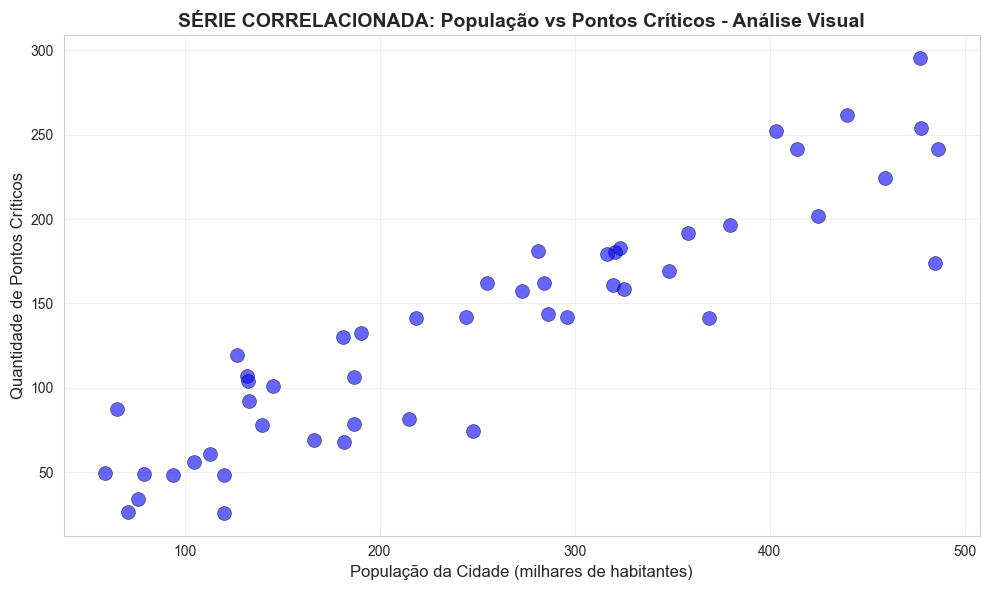

Scatter Plot - Série Correlacionada gerado com sucesso!


In [3]:
# Criar o scatter plot para série correlacionada
plt.figure(figsize=(10, 6))
plt.scatter(X, Y_corr, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, color='blue')
plt.xlabel('População da Cidade (milhares de habitantes)', fontsize=12)
plt.ylabel('Quantidade de Pontos Críticos', fontsize=12)
plt.title('SÉRIE CORRELACIONADA: População vs Pontos Críticos - Análise Visual', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Scatter Plot - Série Correlacionada gerado com sucesso!")

### Interpretação do Scatter Plot - Série Correlacionada

**Observações:**
- Os pontos formam uma **nuvem inclinada para cima** (da esquerda para a direita)
- Isso indica uma **relação positiva** entre população e pontos críticos
- Cidades com maior população tendem a ter mais pontos críticos
- Existe dispersão dos pontos, indicando que não é uma relação perfeita

## PASSO 2: Regressão Linear - Série Correlacionada

In [4]:
# Ajustar modelo de regressão linear para série correlacionada
X_reshape = X.reshape(-1, 1)
modelo_corr = LinearRegression()
modelo_corr.fit(X_reshape, Y_corr)

# Obter parâmetros
a_corr = modelo_corr.intercept_
b_corr = modelo_corr.coef_[0]
Y_pred_corr = modelo_corr.predict(X_reshape)

# Gerar pontos para a linha de tendência
X_linha = np.array([X.min(), X.max()]).reshape(-1, 1)
Y_linha_corr = modelo_corr.predict(X_linha)

print(f"SÉRIE CORRELACIONADA:")
print(f"Equação de Regressão: Y = {a_corr:.2f} + {b_corr:.4f}*X")
print(f"Intercept (a) = {a_corr:.4f}")
print(f"Coeficiente Angular (b) = {b_corr:.4f}")

SÉRIE CORRELACIONADA:
Equação de Regressão: Y = 13.65 + 0.4851*X
Intercept (a) = 13.6455
Coeficiente Angular (b) = 0.4851


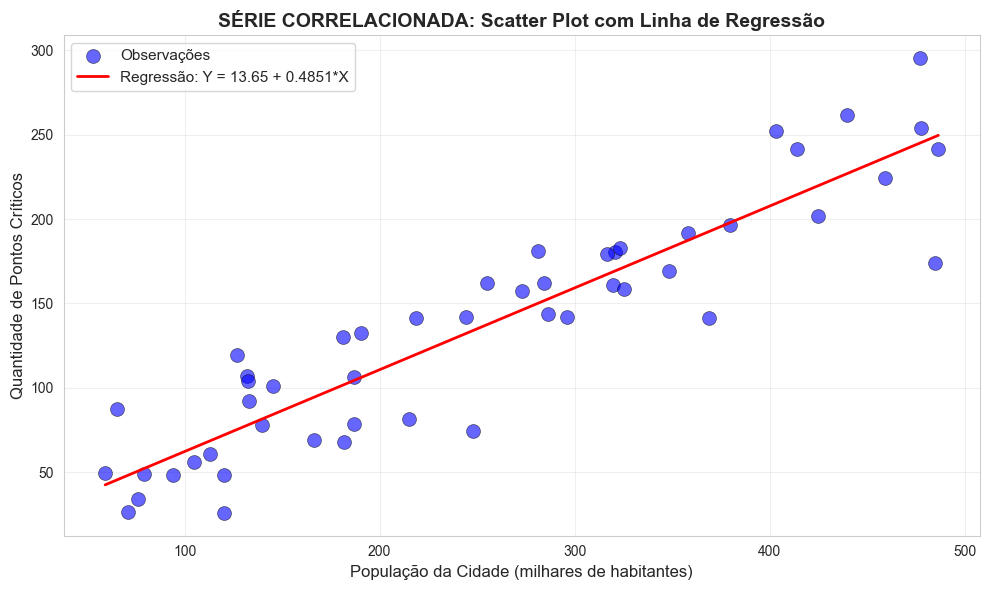

In [5]:
# Plotar scatter plot com linha de regressão - série correlacionada
plt.figure(figsize=(10, 6))
plt.scatter(X, Y_corr, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, label='Observações', color='blue')
plt.plot(X_linha, Y_linha_corr, color='red', linewidth=2, label=f'Regressão: Y = {a_corr:.2f} + {b_corr:.4f}*X')
plt.xlabel('População da Cidade (milhares de habitantes)', fontsize=12)
plt.ylabel('Quantidade de Pontos Críticos', fontsize=12)
plt.title('SÉRIE CORRELACIONADA: Scatter Plot com Linha de Regressão', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PASSO 3 & 4: Análise Estatística - Série Correlacionada

In [6]:
# Análise estatística para série correlacionada
R_squared_corr = modelo_corr.score(X_reshape, Y_corr)

# Correlação de Pearson
r_corr, p_value_corr = stats.pearsonr(X, Y_corr)

# Teste t para o coeficiente angular
SS_total_corr = np.sum((Y_corr - np.mean(Y_corr))**2)
SS_residual_corr = np.sum((Y_corr - Y_pred_corr)**2)
df_residual_corr = len(Y_corr) - 2
MS_residual_corr = SS_residual_corr / df_residual_corr
std_error_b_corr = np.sqrt(MS_residual_corr / np.sum((X - np.mean(X))**2))
t_statistic_corr = b_corr / std_error_b_corr
p_value_t_corr = 2 * (1 - stats.t.cdf(abs(t_statistic_corr), df_residual_corr))

print("="*70)
print(" "*15 + "ANÁLISE ESTATÍSTICA - SÉRIE CORRELACIONADA")
print("="*70)
print(f"\n1. CORRELAÇÃO DE PEARSON:")
print(f"   r = {r_corr:.6f}")
print(f"   p-value = {p_value_corr:.6f}")
print(f"   R² = {R_squared_corr:.6f}")
print(f"   {R_squared_corr*100:.2f}% da variação é explicada pela população")

print(f"\n2. COEFICIENTE ANGULAR (b):")
print(f"   b = {b_corr:.6f}")
print(f"   p-value = {p_value_t_corr:.6f}")
if p_value_t_corr < 0.05:
    print(f"   ✓ Estatisticamente significativo (p < 0.05)")
else:
    print(f"   ✗ Não é estatisticamente significativo")
print("="*70)

               ANÁLISE ESTATÍSTICA - SÉRIE CORRELACIONADA

1. CORRELAÇÃO DE PEARSON:
   r = 0.916672
   p-value = 0.000000
   R² = 0.840287
   84.03% da variação é explicada pela população

2. COEFICIENTE ANGULAR (b):
   b = 0.485104
   p-value = 0.000000
   ✓ Estatisticamente significativo (p < 0.05)


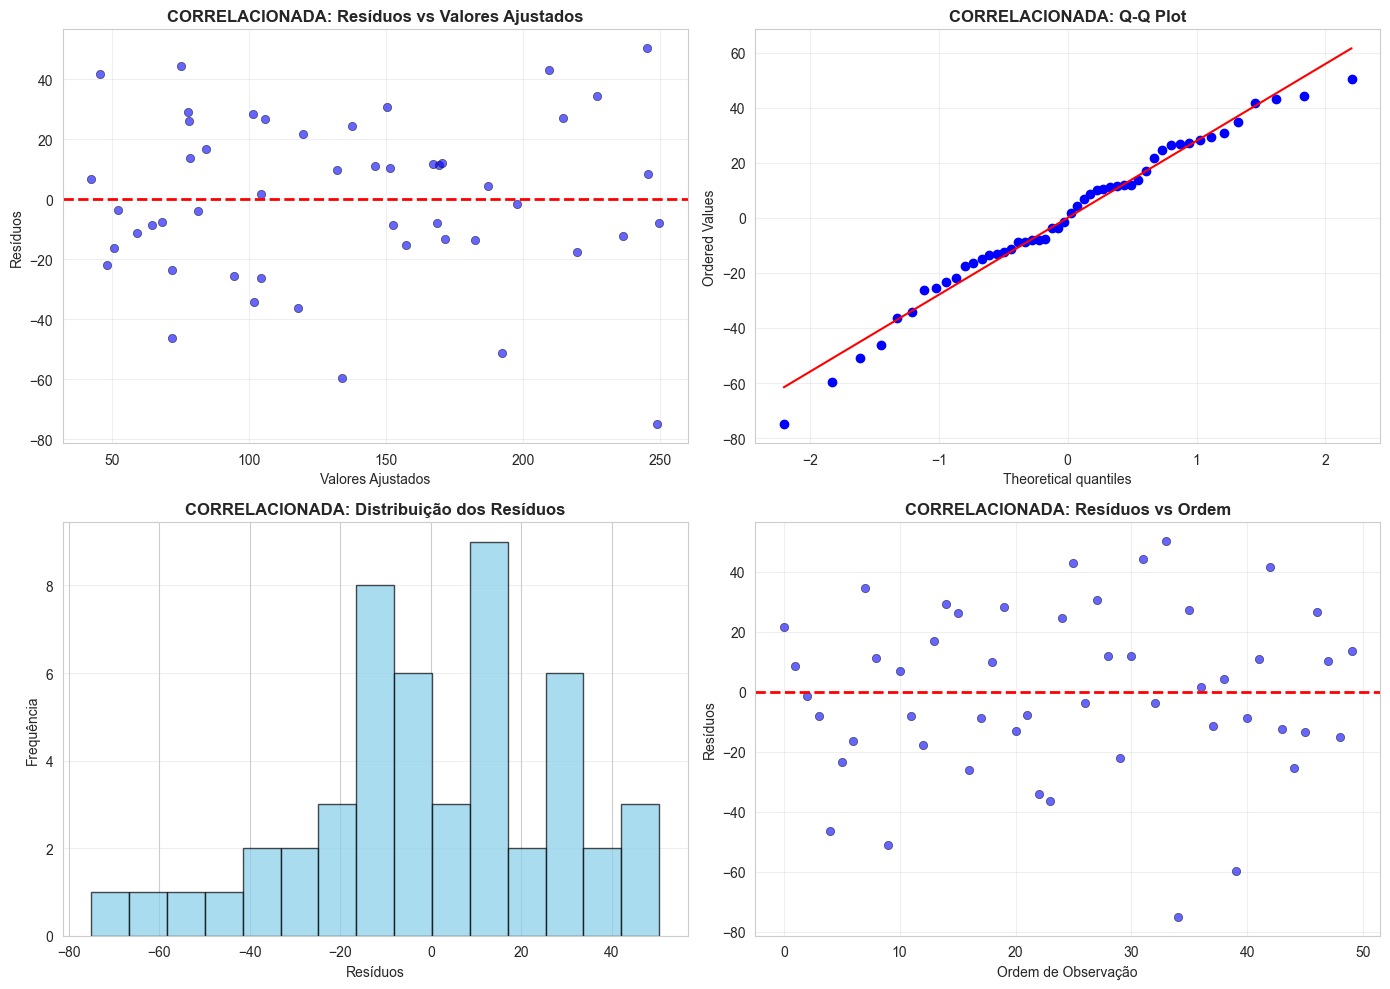

In [7]:
# Análise de resíduos - série correlacionada
residuos_corr = Y_corr - Y_pred_corr

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Resíduos vs Valores Ajustados
axes[0, 0].scatter(Y_pred_corr, residuos_corr, alpha=0.6, edgecolors='k', linewidth=0.5, color='blue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Resíduos')
axes[0, 0].set_title('CORRELACIONADA: Resíduos vs Valores Ajustados', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. QQ-plot
stats.probplot(residuos_corr, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('CORRELACIONADA: Q-Q Plot', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma dos Resíduos
axes[1, 0].hist(residuos_corr, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].set_xlabel('Resíduos')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('CORRELACIONADA: Distribuição dos Resíduos', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Resíduos vs Ordem de Observação
axes[1, 1].scatter(range(len(residuos_corr)), residuos_corr, alpha=0.6, edgecolors='k', linewidth=0.5, color='blue')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Ordem de Observação')
axes[1, 1].set_ylabel('Resíduos')
axes[1, 1].set_title('CORRELACIONADA: Resíduos vs Ordem', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# PARTE 2: ANÁLISE DA SÉRIE NÃO-CORRELACIONADA

## PASSO 1: Scatter Plot - Série Não-Correlacionada

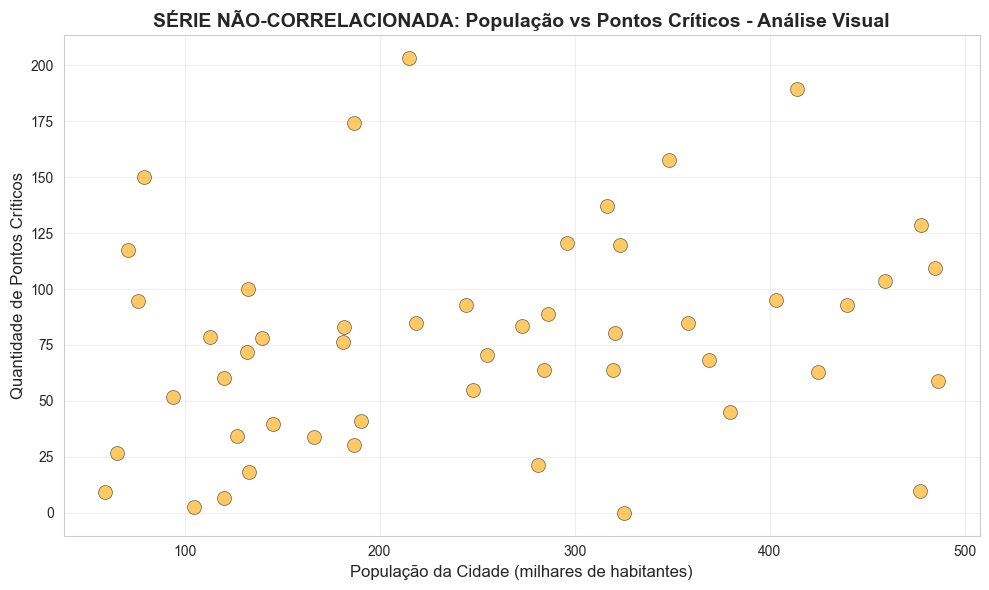

Scatter Plot - Série Não-Correlacionada gerado com sucesso!


In [8]:
# Criar o scatter plot para série não-correlacionada
plt.figure(figsize=(10, 6))
plt.scatter(X, Y_nao_corr, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, color='orange')
plt.xlabel('População da Cidade (milhares de habitantes)', fontsize=12)
plt.ylabel('Quantidade de Pontos Críticos', fontsize=12)
plt.title('SÉRIE NÃO-CORRELACIONADA: População vs Pontos Críticos - Análise Visual', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Scatter Plot - Série Não-Correlacionada gerado com sucesso!")

### Interpretação do Scatter Plot - Série Não-Correlacionada

**Observações:**
- Os pontos estão **espalhados aleatoriamente** em torno de uma faixa horizontal
- Não há uma tendência clara (não inclinam para cima nem para baixo)
- Isso indica **pouca ou nenhuma correlação** entre população e pontos críticos
- Os pontos críticos variam independentemente da população

## PASSO 2: Regressão Linear - Série Não-Correlacionada

In [9]:
# Ajustar modelo de regressão linear para série não-correlacionada
modelo_nao_corr = LinearRegression()
modelo_nao_corr.fit(X_reshape, Y_nao_corr)

# Obter parâmetros
a_nao_corr = modelo_nao_corr.intercept_
b_nao_corr = modelo_nao_corr.coef_[0]
Y_pred_nao_corr = modelo_nao_corr.predict(X_reshape)

# Gerar pontos para a linha de tendência
Y_linha_nao_corr = modelo_nao_corr.predict(X_linha)

print(f"SÉRIE NÃO-CORRELACIONADA:")
print(f"Equação de Regressão: Y = {a_nao_corr:.2f} + {b_nao_corr:.4f}*X")
print(f"Intercept (a) = {a_nao_corr:.4f}")
print(f"Coeficiente Angular (b) = {b_nao_corr:.4f}")
print(f"\nObserve que b está muito próximo de 0, indicando relação fraca!")

SÉRIE NÃO-CORRELACIONADA:
Equação de Regressão: Y = 56.87 + 0.0821*X
Intercept (a) = 56.8738
Coeficiente Angular (b) = 0.0821

Observe que b está muito próximo de 0, indicando relação fraca!


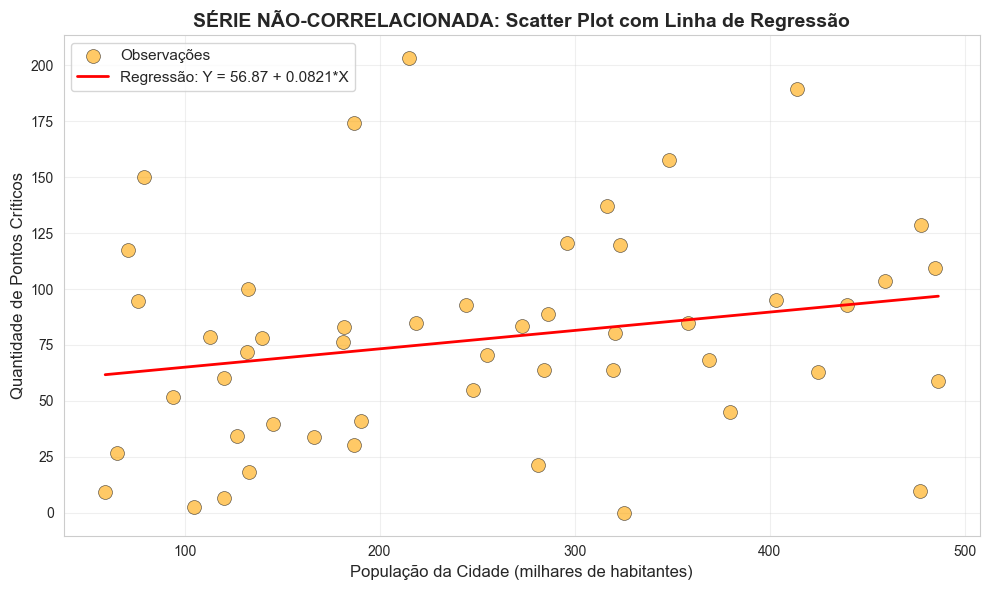

In [10]:
# Plotar scatter plot com linha de regressão - série não-correlacionada
plt.figure(figsize=(10, 6))
plt.scatter(X, Y_nao_corr, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, label='Observações', color='orange')
plt.plot(X_linha, Y_linha_nao_corr, color='red', linewidth=2, label=f'Regressão: Y = {a_nao_corr:.2f} + {b_nao_corr:.4f}*X')
plt.xlabel('População da Cidade (milhares de habitantes)', fontsize=12)
plt.ylabel('Quantidade de Pontos Críticos', fontsize=12)
plt.title('SÉRIE NÃO-CORRELACIONADA: Scatter Plot com Linha de Regressão', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PASSO 3 & 4: Análise Estatística - Série Não-Correlacionada

In [11]:
# Análise estatística para série não-correlacionada
R_squared_nao_corr = modelo_nao_corr.score(X_reshape, Y_nao_corr)

# Correlação de Pearson
r_nao_corr, p_value_nao_corr = stats.pearsonr(X, Y_nao_corr)

# Teste t para o coeficiente angular
SS_total_nao_corr = np.sum((Y_nao_corr - np.mean(Y_nao_corr))**2)
SS_residual_nao_corr = np.sum((Y_nao_corr - Y_pred_nao_corr)**2)
df_residual_nao_corr = len(Y_nao_corr) - 2
MS_residual_nao_corr = SS_residual_nao_corr / df_residual_nao_corr
std_error_b_nao_corr = np.sqrt(MS_residual_nao_corr / np.sum((X - np.mean(X))**2))
t_statistic_nao_corr = b_nao_corr / std_error_b_nao_corr
p_value_t_nao_corr = 2 * (1 - stats.t.cdf(abs(t_statistic_nao_corr), df_residual_nao_corr))

print("="*70)
print(" "*12 + "ANÁLISE ESTATÍSTICA - SÉRIE NÃO-CORRELACIONADA")
print("="*70)
print(f"\n1. CORRELAÇÃO DE PEARSON:")
print(f"   r = {r_nao_corr:.6f}")
print(f"   p-value = {p_value_nao_corr:.6f}")
print(f"   R² = {R_squared_nao_corr:.6f}")
print(f"   {R_squared_nao_corr*100:.2f}% da variação é explicada pela população")

print(f"\n2. COEFICIENTE ANGULAR (b):")
print(f"   b = {b_nao_corr:.6f}")
print(f"   p-value = {p_value_t_nao_corr:.6f}")
if p_value_t_nao_corr < 0.05:
    print(f"   ✓ Estatisticamente significativo (p < 0.05)")
else:
    print(f"   ✗ Não é estatisticamente significativo (p ≥ 0.05)")
print("="*70)

            ANÁLISE ESTATÍSTICA - SÉRIE NÃO-CORRELACIONADA

1. CORRELAÇÃO DE PEARSON:
   r = 0.223396
   p-value = 0.118884
   R² = 0.049906
   4.99% da variação é explicada pela população

2. COEFICIENTE ANGULAR (b):
   b = 0.082076
   p-value = 0.118884
   ✗ Não é estatisticamente significativo (p ≥ 0.05)


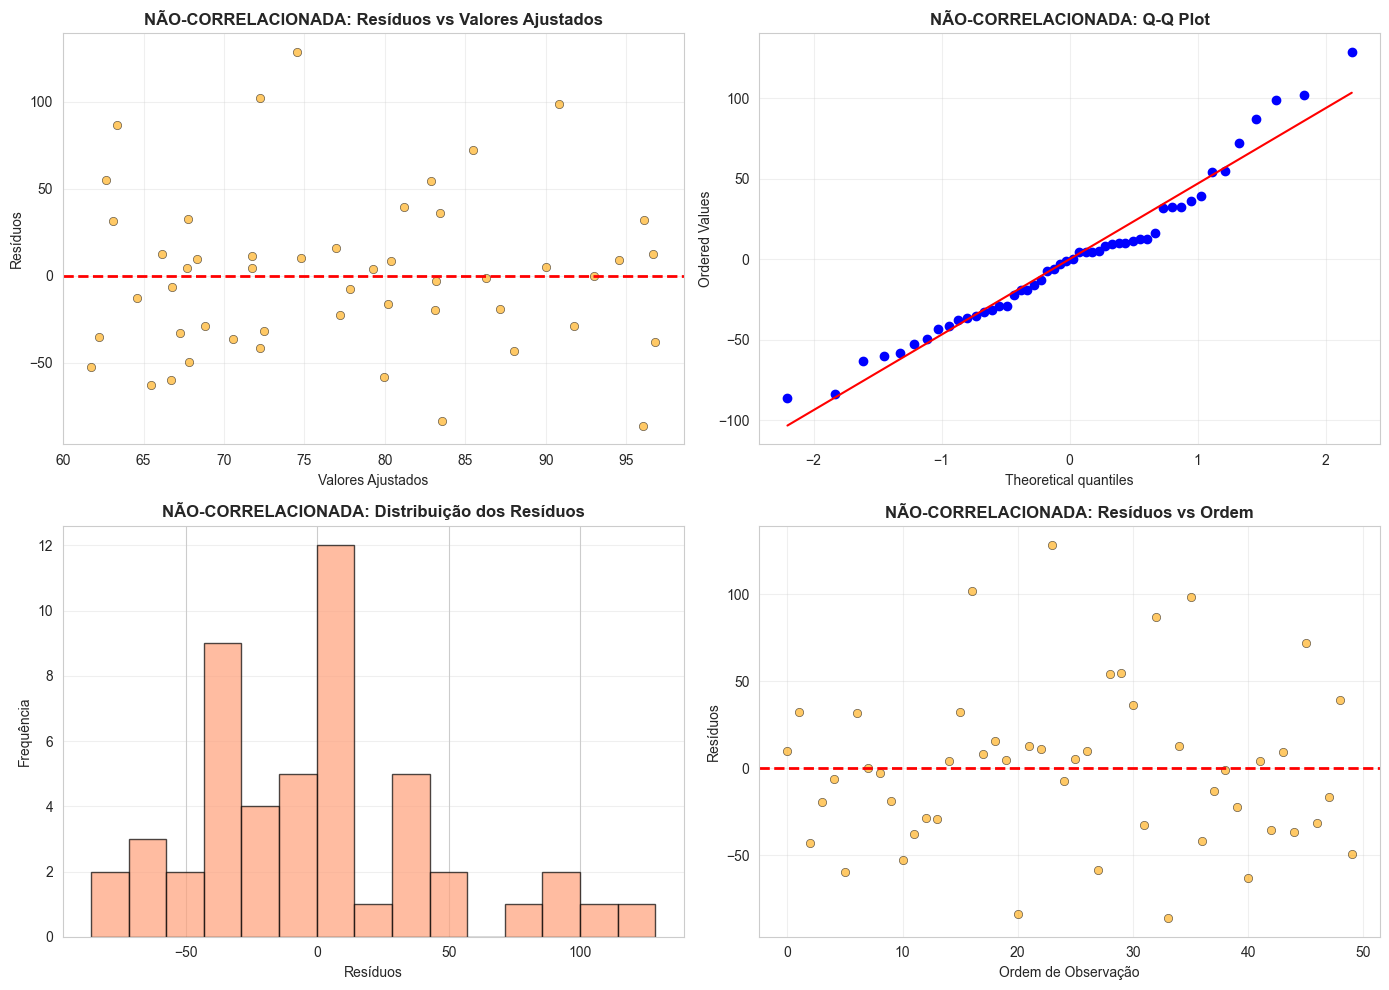

In [12]:
# Análise de resíduos - série não-correlacionada
residuos_nao_corr = Y_nao_corr - Y_pred_nao_corr

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Resíduos vs Valores Ajustados
axes[0, 0].scatter(Y_pred_nao_corr, residuos_nao_corr, alpha=0.6, edgecolors='k', linewidth=0.5, color='orange')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Resíduos')
axes[0, 0].set_title('NÃO-CORRELACIONADA: Resíduos vs Valores Ajustados', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. QQ-plot
stats.probplot(residuos_nao_corr, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('NÃO-CORRELACIONADA: Q-Q Plot', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma dos Resíduos
axes[1, 0].hist(residuos_nao_corr, bins=15, edgecolor='black', alpha=0.7, color='lightsalmon')
axes[1, 0].set_xlabel('Resíduos')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('NÃO-CORRELACIONADA: Distribuição dos Resíduos', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Resíduos vs Ordem de Observação
axes[1, 1].scatter(range(len(residuos_nao_corr)), residuos_nao_corr, alpha=0.6, edgecolors='k', linewidth=0.5, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Ordem de Observação')
axes[1, 1].set_ylabel('Resíduos')
axes[1, 1].set_title('NÃO-CORRELACIONADA: Resíduos vs Ordem', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# PARTE 3: COMPARAÇÃO VISUAL - LADO A LADO

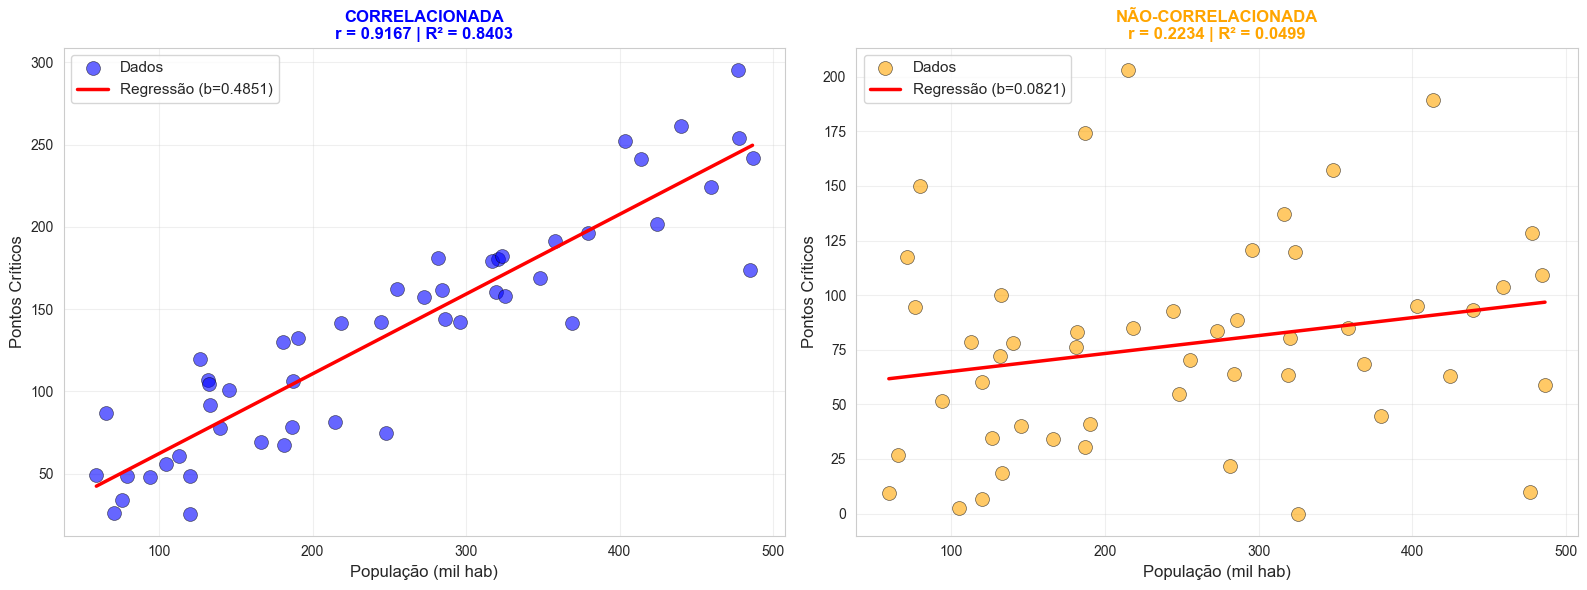

In [13]:
# Comparação visual lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Série Correlacionada
axes[0].scatter(X, Y_corr, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, color='blue', label='Dados')
axes[0].plot(X_linha, Y_linha_corr, color='red', linewidth=2.5, label=f'Regressão (b={b_corr:.4f})')
axes[0].set_xlabel('População (mil hab)', fontsize=12)
axes[0].set_ylabel('Pontos Críticos', fontsize=12)
axes[0].set_title(f'CORRELACIONADA\nr = {r_corr:.4f} | R² = {R_squared_corr:.4f}', 
                  fontsize=12, fontweight='bold', color='blue')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Série Não-Correlacionada
axes[1].scatter(X, Y_nao_corr, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, color='orange', label='Dados')
axes[1].plot(X_linha, Y_linha_nao_corr, color='red', linewidth=2.5, label=f'Regressão (b={b_nao_corr:.4f})')
axes[1].set_xlabel('População (mil hab)', fontsize=12)
axes[1].set_ylabel('Pontos Críticos', fontsize=12)
axes[1].set_title(f'NÃO-CORRELACIONADA\nr = {r_nao_corr:.4f} | R² = {R_squared_nao_corr:.4f}', 
                  fontsize=12, fontweight='bold', color='orange')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# PARTE 4: RESUMO COMPARATIVO

In [14]:
# Criar tabela comparativa
comparacao = pd.DataFrame({
    'Métrica': ['Correlação Pearson (r)', 'P-value Pearson', 'R² (coeficiente determinação)', 
                'Coeficiente Angular (b)', 'P-value b', 'Intercepto (a)',
                'Significância b', 'Interpretação'],
    'Correlacionada': [
        f'{r_corr:.6f}',
        f'{p_value_corr:.6f}',
        f'{R_squared_corr:.6f}',
        f'{b_corr:.6f}',
        f'{p_value_t_corr:.6f}',
        f'{a_corr:.6f}',
        'SIM ✓' if p_value_t_corr < 0.05 else 'NÃO ✗',
        'Forte relação linear'
    ],
    'Não-Correlacionada': [
        f'{r_nao_corr:.6f}',
        f'{p_value_nao_corr:.6f}',
        f'{R_squared_nao_corr:.6f}',
        f'{b_nao_corr:.6f}',
        f'{p_value_t_nao_corr:.6f}',
        f'{a_nao_corr:.6f}',
        'SIM ✓' if p_value_t_nao_corr < 0.05 else 'NÃO ✗',
        'Relação fraca/nula'
    ]
})

print("\n" + "="*90)
print(" "*20 + "TABELA COMPARATIVA: CORRELACIONADA VS NÃO-CORRELACIONADA")
print("="*90)
print(comparacao.to_string(index=False))
print("="*90)


                    TABELA COMPARATIVA: CORRELACIONADA VS NÃO-CORRELACIONADA
                      Métrica       Correlacionada Não-Correlacionada
       Correlação Pearson (r)             0.916672           0.223396
              P-value Pearson             0.000000           0.118884
R² (coeficiente determinação)             0.840287           0.049906
      Coeficiente Angular (b)             0.485104           0.082076
                    P-value b             0.000000           0.118884
               Intercepto (a)            13.645458          56.873833
              Significância b                SIM ✓              NÃO ✗
                Interpretação Forte relação linear Relação fraca/nula


## Interpretação da Correlação de Pearson

| Valor de r | Interpretação |
|:---:|:---|
| 0.7 a 1.0 | **Correlação forte positiva** - Relação linear forte e positiva |
| 0.3 a 0.7 | **Correlação moderada** - Existe relação linear, mas com dispersão notável |
| 0.0 a 0.3 | **Correlação fraca** - Relação linear fraca ou praticamente ausente |
| 0 | **Sem correlação** - Não há relação linear detectável |
| -0.3 a -1.0 | **Valores negativos** - Relação inversa (uma aumenta, outra diminui) |

---
# CONCLUSÕES FINAIS

In [15]:
print("\n" + "="*90)
print(" "*25 + "CONCLUSÕES FINAIS E INTERPRETAÇÕES")
print("="*90)

print(f"\n📊 SÉRIE CORRELACIONADA:")
print(f"   • Correlação: r = {r_corr:.4f}")
if abs(r_corr) >= 0.7:
    print(f"     → FORTE correlação (|r| ≥ 0.7)")
elif abs(r_corr) >= 0.3:
    print(f"     → MODERADA correlação (0.3 ≤ |r| < 0.7)")
else:
    print(f"     → FRACA correlação (|r| < 0.3)")

print(f"   • Coeficiente Angular: b = {b_corr:.4f}")
if p_value_t_corr < 0.05:
    print(f"     → SIGNIFICATIVO (p = {p_value_t_corr:.6f} < 0.05)")
    print(f"     → Cidades maiores têm MAIS pontos críticos" if b_corr > 0 else f"     → Cidades maiores têm MENOS pontos críticos")
else:
    print(f"     → NÃO SIGNIFICATIVO (p = {p_value_t_corr:.6f} ≥ 0.05)")

print(f"   • R² = {R_squared_corr:.4f}")
print(f"     → {R_squared_corr*100:.2f}% da variação em Y é explicada por X")
print(f"     → {(1-R_squared_corr)*100:.2f}% é devido a outros fatores")

print(f"\n📊 SÉRIE NÃO-CORRELACIONADA:")
print(f"   • Correlação: r = {r_nao_corr:.4f}")
if abs(r_nao_corr) >= 0.7:
    print(f"     → FORTE correlação (|r| ≥ 0.7)")
elif abs(r_nao_corr) >= 0.3:
    print(f"     → MODERADA correlação (0.3 ≤ |r| < 0.7)")
else:
    print(f"     → FRACA/NENHUMA correlação (|r| < 0.3)")

print(f"   • Coeficiente Angular: b = {b_nao_corr:.4f}")
if p_value_t_nao_corr < 0.05:
    print(f"     → SIGNIFICATIVO (p = {p_value_t_nao_corr:.6f} < 0.05)")
else:
    print(f"     → NÃO SIGNIFICATIVO (p = {p_value_t_nao_corr:.6f} ≥ 0.05)")
    print(f"     → Não há relação linear clara entre X e Y")

print(f"   • R² = {R_squared_nao_corr:.4f}")
print(f"     → {R_squared_nao_corr*100:.2f}% da variação em Y é explicada por X")
print(f"     → {(1-R_squared_nao_corr)*100:.2f}% é devido a outros fatores (praticamente tudo!)")

print(f"\n🔍 DIFERENÇAS PRINCIPAIS:")
print(f"   • Inclinação: Correlacionada ({b_corr:.4f}) > Não-correlacionada ({b_nao_corr:.4f})")
print(f"     → Diferença de {abs(b_corr - b_nao_corr):.4f}")
print(f"\n   • Correlação: Correlacionada ({r_corr:.4f}) >> Não-correlacionada ({r_nao_corr:.4f})")
print(f"\n   • R²: Correlacionada ({R_squared_corr:.4f}) >> Não-correlacionada ({R_squared_nao_corr:.4f})")
print(f"     → A série correlacionada explica {(R_squared_corr - R_squared_nao_corr)*100:.2f}% MAIS da variação")

print(f"\n✅ CONCLUSÃO:")
print(f"   • SÉRIE CORRELACIONADA: Existe uma relação LINEAR significativa com a população")
print(f"   • SÉRIE NÃO-CORRELACIONADA: NÃO existe relação linear com a população")
print(f"   • Este exemplo ilustra a diferença entre dados com e sem correlação!")

print("\n" + "="*90)


                         CONCLUSÕES FINAIS E INTERPRETAÇÕES

📊 SÉRIE CORRELACIONADA:
   • Correlação: r = 0.9167
     → FORTE correlação (|r| ≥ 0.7)
   • Coeficiente Angular: b = 0.4851
     → SIGNIFICATIVO (p = 0.000000 < 0.05)
     → Cidades maiores têm MAIS pontos críticos
   • R² = 0.8403
     → 84.03% da variação em Y é explicada por X
     → 15.97% é devido a outros fatores

📊 SÉRIE NÃO-CORRELACIONADA:
   • Correlação: r = 0.2234
     → FRACA/NENHUMA correlação (|r| < 0.3)
   • Coeficiente Angular: b = 0.0821
     → NÃO SIGNIFICATIVO (p = 0.118884 ≥ 0.05)
     → Não há relação linear clara entre X e Y
   • R² = 0.0499
     → 4.99% da variação em Y é explicada por X
     → 95.01% é devido a outros fatores (praticamente tudo!)

🔍 DIFERENÇAS PRINCIPAIS:
   • Inclinação: Correlacionada (0.4851) > Não-correlacionada (0.0821)
     → Diferença de 0.4030

   • Correlação: Correlacionada (0.9167) >> Não-correlacionada (0.2234)

   • R²: Correlacionada (0.8403) >> Não-correlacionada (0.04

---
# APÊNDICE: Análise com Amostras Pequenas (por exemplo: 5 Pontos)

## O Dilema do Tamanho da Amostra: Será que funciona com poucos dados?

Uma pergunta natural surge: **"E se tivéssemos apenas 5 observações em vez de 50?"**

Esta é uma questão crítica em estatística porque o tamanho da amostra (n) tem um impacto profundo na confiabilidade dos resultados.

### Por que o tamanho da amostra é importante?

#### 1. **Graus de Liberdade (df)**

O número de graus de liberdade em regressão linear é: $df = n - 2$

Onde:
- Com n = 50: df = 48 (muita liberdade para estimar a verdadeira relação)
- Com n = 5: df = 3 (muito poucas observações para confiar no modelo)

**Impacto direto:** O teste estatístico (teste t) usa df para calcular se b é significativo. Com df pequeno, o t crítico cresce, tornando mais difícil rejeitar H₀.

#### 2. **Erro Padrão da Regressão Aumenta**

O erro padrão de b é: $SE_b = \sqrt{\frac{\text{Variância Residual}}{\sum(x_i - \bar{x})^2}}$

Com poucos pontos:
- Estimativas de variância são menos confiáveis
- O denominador é menor (menos dispersão em X)
- Resultado: SE_b fica muito grande

#### 3. **Correlação Spureia (Enganosa)**

Uma correlação falsamente alta pode surgir com poucos pontos. Por exemplo:
- Com 2 pontos: sempre r = ±1 (correlação perfeita!) - mas não significa nada!
- Com 3-5 pontos: correlações podem ser altas por puro acaso, não por relação verdadeira

#### 4. **Indeterminação vs Determinação**

Com 2 pontos:
- Ajusta uma linha de regressão perfeitamente (R² = 1)
- Mas não há resíduo para testar (0 graus de liberdade)

Com 3 pontos:
- Possível testar significância (1 grau de liberdade)
- Mas os intervalos de confiança são ENORMES

Com 5 pontos:
- Tecnicamente possível
- Mas resultados muito instáveis e pouco confiáveis

### Exemplo: O que mudaria com 5 pontos?

Suponha que selecionássemos apenas 5 cidades de nossa base de 50:

**Cenário 1: 5 pontos bem selecionados**
- Pode resultar em uma correlação bem alta (enganosa)
- P-value pode ser enganosamente baixo
- R² pode parecer promissor
- MAS: Muito sensível a outliers

**Cenário 2: 5 pontos mal selecionados**
- Correlação baixa (mesmo que exista verdadeira correlação)
- P-value alto (erro tipo II: não detectar correlação real)
- R² baixo
- Conclusão errônea: "não há correlação" (quando há!)

**Variabilidade:** Se repetíssemos a amostragem aleatória 1000 vezes:
- Com n=50: resultados relativamente estáveis
- Com n=5: resultados MUITO variáveis, r poderia variar de -0.8 a +0.8!

### Recomendações Práticas

| Aspecto | Recomendação |
|:---|:---|
| **Tamanho mínimo de amostra** | n ≥ 30 para testes de significância (regra prática) |
| **Mínimo absoluto** | n ≥ 3 (para calcular regressão linear) |
| **Ideal para confiança alta** | n ≥ 100 ou mais (especialmente em pesquisa) |
| **Com n = 5** | Descritivo apenas, SEM testes estatísticos formais |
| **Com n < 30** | Use cuidado extremo, considere métodos não-paramétricos |

### Fórmula do Erro Padrão em Função de n

Para uma regressão linear com dados similares:

$$SE_b \propto \frac{1}{\sqrt{n}}$$

Isso significa:
- Reduzir n de 50 para 5 (10x menor):
- SE_b aumenta por √10 ≈ 3.16 vezes
- Intervalo de confiança fica 3x mais largo!

### Conclusão sobre Amostras Pequenas

**PODE usar 5 pontos para:**
- ✓ Análise exploratória e descritiva
- ✓ Gerar hipóteses (não testá-las)
- ✓ Visualizar relações potenciais
- ✓ Casos onde é impossível coletar mais dados

**NÃO deve usar 5 pontos para:**
- ✗ Testar significância estatística (p-values não são confiáveis)
- ✗ Fazer inferências sobre a população
- ✗ Tomar decisões críticas baseadas em p < 0.05
- ✗ Publicar como resultado definitivo

**Lei de Ouro:** Sempre mencione o tamanho da amostra e suas limitações!

Com dados reais sobre cidades e pontos críticos, recomenda-se:
- **Mínimo 30+ cidades** para correlação confiável
- **50+ cidades** para análise robusta
- **100+ cidades** para alto nível de confiança